<a href="https://colab.research.google.com/github/Shreyas0744/Car-Price-Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Your Specific URL (Converted to RAW format)
# Note: I added '?raw=true' to your link so the code can read the actual data
url = "https://github.com/Shreyas0744/Car-Price-Prediction/blob/main/car_price_prediction_.csv?raw=true"

# Load the Dataset
try:
    df = pd.read_csv(url)
    print("Dataset successfully loaded from your GitHub!")
    print(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")

Dataset successfully loaded from your GitHub!
   Car ID  Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition  \
0       1  Tesla  2016          2.3    Petrol       Manual   114832       New   
1       2    BMW  2018          4.4  Electric       Manual   143190      Used   
2       3   Audi  2013          4.5  Electric       Manual   181601       New   
3       4  Tesla  2011          4.1    Diesel    Automatic    68682       New   
4       5   Ford  2009          2.6    Diesel       Manual   223009  Like New   

      Price     Model  
0  26613.92   Model X  
1  14679.61  5 Series  
2  44402.61        A4  
3  86374.33   Model Y  
4  73577.10   Mustang  


In [8]:
# Data Preprocessing
# Note: Ensure these column names match your CSV exactly
# We create a 'Car_Age' feature which is better for regression
current_year = 2026
if 'Year' in df.columns:
    df['Car_Age'] = current_year - df['Year']
    df.drop(['Year'], axis=1, inplace=True)

# Identify non-numeric columns to encode them
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Split Data (Assuming 'Price' is your target column)
target_col = 'Price' # Change this if your CSV uses a different name like 'Price'
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Model R2 Score: -0.03


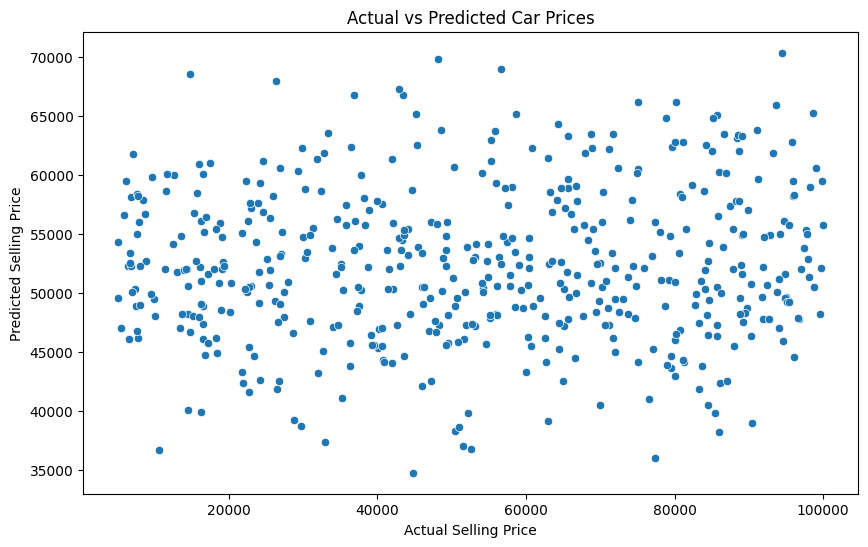

In [9]:
# Build and Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. Results & Visualization
predictions = model.predict(X_test)
print(f"\nModel R2 Score: {r2_score(y_test, predictions):.2f}")

plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=predictions)
plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.show()